# Liora Project 3: What Pitch Should Tarik Skubal Throw?

**Phase 1: Exploratory Data Analysis (EDA)**

Source: MLB Statcast pitch-level parquet files (one per season, 2015-2026), pulled via the `pybaseball` library.

Pitcher of interest: **Tarik Skubal**, LHP, Detroit Tigers (MLBAM ID `669373`, MLB debut 2020).

Goal of this notebook: load Skubal's career Statcast rows, inspect schema, count rows per season, profile his pitch arsenal, look at velocity/spin distributions, examine count situations, and define a baseline target (next pitch_type) for the modelling phase.

In [1]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

DATA_DIR = '/root/AI/liora_projects/03_skubal_pitch/data'
SKUBAL_ID = 669373  # MLBAM player ID for Tarik Skubal

files = sorted(glob.glob(os.path.join(DATA_DIR, 'statcast_*.parquet')))
print(f'Found {len(files)} season parquet files:')
for f in files:
    print(' ', os.path.basename(f), f'{os.path.getsize(f)/1e6:.1f} MB')

Found 12 season parquet files:
  statcast_2015.parquet 70.7 MB
  statcast_2016.parquet 72.8 MB
  statcast_2017.parquet 93.5 MB
  statcast_2018.parquet 90.9 MB
  statcast_2019.parquet 93.0 MB
  statcast_2020.parquet 36.4 MB
  statcast_2021.parquet 92.8 MB
  statcast_2022.parquet 93.2 MB
  statcast_2023.parquet 101.3 MB
  statcast_2024.parquet 108.8 MB
  statcast_2025.parquet 111.0 MB
  statcast_2026.parquet 24.2 MB


## 1. Schema inspection (single season)

Load one season to see the Statcast pitch-level schema. The Statcast feed has ~118 columns covering pitch physics (release speed, spin, axis, break), location, count state, batter/pitcher IDs, and outcome (`description`, `events`, `delta_run_exp`).

In [2]:
sample = pd.read_parquet(os.path.join(DATA_DIR, 'statcast_2024.parquet'))
print('2024 shape:', sample.shape)
print('Columns:', len(sample.columns))
sample.dtypes.head(40)

2024 shape: (760248, 118)
Columns: 118


pitch_type                         object
game_date                  datetime64[ns]
release_speed                     Float64
release_pos_x                     Float64
release_pos_z                     Float64
player_name                        object
batter                              Int64
pitcher                             Int64
events                             object
description                        object
spin_dir                            Int64
spin_rate_deprecated                Int64
break_angle_deprecated              Int64
break_length_deprecated             Int64
zone                                Int64
des                                object
game_type                          object
stand                              object
p_throws                           object
home_team                          object
away_team                          object
type                               object
hit_location                        Int64
bb_type                           

In [3]:
# Group columns by domain to make the schema easier to digest.
groups = {
    'identifiers': ['game_pk','game_date','game_year','at_bat_number','pitch_number','pitcher','batter','player_name'],
    'pitch_label': ['pitch_type','pitch_name','type','description','events','des'],
    'pitch_physics': ['release_speed','release_spin_rate','release_extension','effective_speed','spin_axis','pfx_x','pfx_z','plate_x','plate_z','vx0','vy0','vz0','ax','ay','az'],
    'count_state': ['balls','strikes','outs_when_up','inning','inning_topbot','on_1b','on_2b','on_3b'],
    'matchup': ['stand','p_throws','home_team','away_team','home_score','away_score','bat_score','fld_score'],
    'batted_ball': ['bb_type','launch_speed','launch_angle','hit_distance_sc','hc_x','hc_y','estimated_woba_using_speedangle','woba_value'],
    'win_prob': ['delta_home_win_exp','delta_run_exp','delta_pitcher_run_exp','home_win_exp','bat_win_exp'],
}
for g, cols in groups.items():
    present = [c for c in cols if c in sample.columns]
    print(f'{g:14s} ({len(present)}): {present}')

identifiers    (8): ['game_pk', 'game_date', 'game_year', 'at_bat_number', 'pitch_number', 'pitcher', 'batter', 'player_name']
pitch_label    (6): ['pitch_type', 'pitch_name', 'type', 'description', 'events', 'des']
pitch_physics  (15): ['release_speed', 'release_spin_rate', 'release_extension', 'effective_speed', 'spin_axis', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az']
count_state    (8): ['balls', 'strikes', 'outs_when_up', 'inning', 'inning_topbot', 'on_1b', 'on_2b', 'on_3b']
matchup        (8): ['stand', 'p_throws', 'home_team', 'away_team', 'home_score', 'away_score', 'bat_score', 'fld_score']
batted_ball    (8): ['bb_type', 'launch_speed', 'launch_angle', 'hit_distance_sc', 'hc_x', 'hc_y', 'estimated_woba_using_speedangle', 'woba_value']
win_prob       (5): ['delta_home_win_exp', 'delta_run_exp', 'delta_pitcher_run_exp', 'home_win_exp', 'bat_win_exp']


## 2. Filter to Skubal across all seasons

We filter on `pitcher == 669373` (MLBAM ID is more reliable than name, but we also confirm `player_name` contains "Skubal"). To stay memory-light we only load the columns needed for EDA.

In [4]:
USE_COLS = [
    'game_pk','game_date','game_year','at_bat_number','pitch_number',
    'pitcher','batter','player_name',
    'pitch_type','pitch_name','type','description','events',
    'release_speed','release_spin_rate','release_extension','spin_axis',
    'pfx_x','pfx_z','plate_x','plate_z',
    'balls','strikes','outs_when_up','inning','inning_topbot',
    'on_1b','on_2b','on_3b',
    'stand','p_throws','home_team','away_team',
    'home_score','away_score','bat_score','fld_score',
    'delta_run_exp','delta_pitcher_run_exp',
    'estimated_woba_using_speedangle','woba_value',
]

frames = []
for fp in files:
    df = pd.read_parquet(fp, columns=USE_COLS)
    sk = df[df['pitcher'] == SKUBAL_ID].copy()
    if len(sk):
        frames.append(sk)
        print(f'{os.path.basename(fp):28s}  Skubal rows: {len(sk):>5d}')
    else:
        print(f'{os.path.basename(fp):28s}  Skubal rows:     0')

skubal = pd.concat(frames, ignore_index=True)
skubal = skubal.sort_values(['game_date','at_bat_number','pitch_number']).reset_index(drop=True)
print('\nTotal Skubal pitches across all seasons:', len(skubal))
print('Sample player_name values:', skubal['player_name'].dropna().unique()[:3])

statcast_2015.parquet         Skubal rows:     0


statcast_2016.parquet         Skubal rows:     0


statcast_2017.parquet         Skubal rows:     0


statcast_2018.parquet         Skubal rows:     0


statcast_2019.parquet         Skubal rows:     0
statcast_2020.parquet         Skubal rows:   591


statcast_2021.parquet         Skubal rows:  2776


statcast_2022.parquet         Skubal rows:  2141


statcast_2023.parquet         Skubal rows:  1219
statcast_2024.parquet         Skubal rows:  3295


statcast_2025.parquet         Skubal rows:  3304
statcast_2026.parquet         Skubal rows:   609

Total Skubal pitches across all seasons: 13935
Sample player_name values: ['Skubal, Tarik']


## 3. Rows per season and games per season

In [5]:
season_summary = skubal.groupby('game_year').agg(
    pitches=('pitch_type','size'),
    games=('game_pk','nunique'),
    pitches_per_game=('pitch_type', lambda s: round(len(s)/skubal.loc[s.index,'game_pk'].nunique(),1)),
    avg_release_speed=('release_speed','mean'),
    avg_spin_rate=('release_spin_rate','mean'),
).round(2)
season_summary

,pitches,games,pitches_per_game,avg_release_speed,avg_spin_rate
game_year,,,,,
2020,591,8,73.9,89.86,2258.56
2021,2776,34,81.6,89.5,2032.27
2022,2141,25,85.6,90.04,2050.03
2023,1219,15,81.3,89.97,2007.11
2024,3295,36,91.5,92.07,2044.6
2025,3304,36,91.8,93.26,2159.55
2026,609,7,87.0,92.41,2160.69


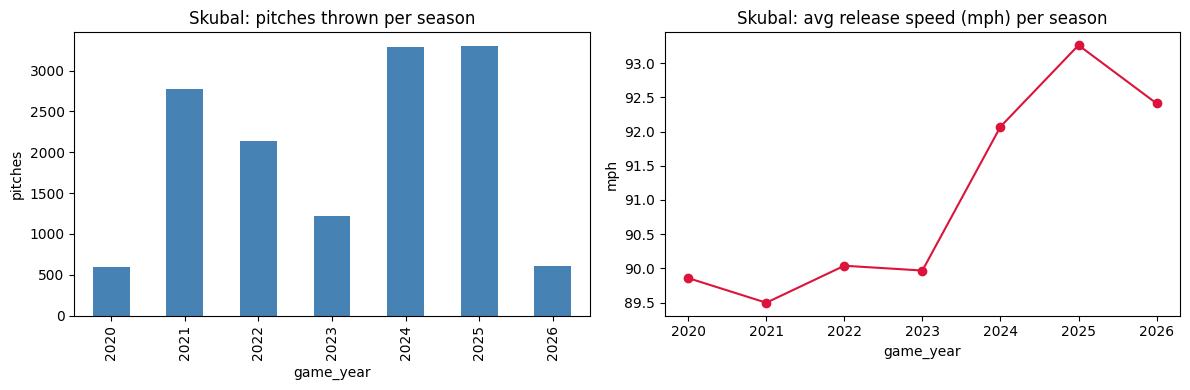

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
season_summary['pitches'].plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Skubal: pitches thrown per season')
ax[0].set_ylabel('pitches')
season_summary['avg_release_speed'].plot(kind='line', marker='o', ax=ax[1], color='crimson')
ax[1].set_title('Skubal: avg release speed (mph) per season')
ax[1].set_ylabel('mph')
plt.tight_layout()
plt.show()

## 4. Pitch-type distribution

Statcast `pitch_type` codes for Skubal: **FF** (4-seam fastball), **SI** (sinker), **SL** (slider), **CH** (changeup), **CU** (curveball), **FS** (splitter), **FC** (cutter, early career only), **KC** (knuckle-curve). NaN/`NA` rows are pitches Statcast could not classify.

In [7]:
overall_mix = skubal['pitch_type'].fillna('NA').value_counts()
overall_mix_pct = (overall_mix / overall_mix.sum() * 100).round(2)
mix_table = pd.concat([overall_mix.rename('count'), overall_mix_pct.rename('pct')], axis=1)
mix_table

,count,pct
pitch_type,,
FF,4906,35.21
CH,3058,21.94
SL,2573,18.46
SI,2462,17.67
CU,697,5.00
NA,120,0.86
FS,97,0.70
FC,19,0.14
KC,3,0.02


In [8]:
season_mix = (
    skubal.assign(pitch_type=skubal['pitch_type'].fillna('NA'))
    .groupby(['game_year','pitch_type']).size().unstack(fill_value=0)
)
season_mix_pct = season_mix.div(season_mix.sum(axis=1), axis=0).mul(100).round(1)
print('Pitch mix by season (counts):')
print(season_mix)
print('\nPitch mix by season (% of pitches):')
print(season_mix_pct)

Pitch mix by season (counts):
pitch_type   CH   CU  FC    FF  FS  KC  NA   SI   SL
game_year                                           
2020         97   46   7   348   0   0   0    0   93
2021        305  190  12  1223  88   3   0  328  627
2022        326  142   0   618   0   0   0  420  635
2023        294   83   0   439   3   0   1  147  252
2024        891  129   0  1073   3   0  34  699  466
2025        987   86   0   970   3   0  84  753  421
2026        158   21   0   235   0   0   1  115   79

Pitch mix by season (% of pitches):
pitch_type    CH   CU   FC    FF   FS   KC   NA    SI    SL
game_year                                                  
2020        16.4  7.8  1.2  58.9  0.0  0.0  0.0   0.0  15.7
2021        11.0  6.8  0.4  44.1  3.2  0.1  0.0  11.8  22.6
2022        15.2  6.6  0.0  28.9  0.0  0.0  0.0  19.6  29.7
2023        24.1  6.8  0.0  36.0  0.2  0.0  0.1  12.1  20.7
2024        27.0  3.9  0.0  32.6  0.1  0.0  1.0  21.2  14.1
2025        29.9  2.6  0.0  29.4  0.

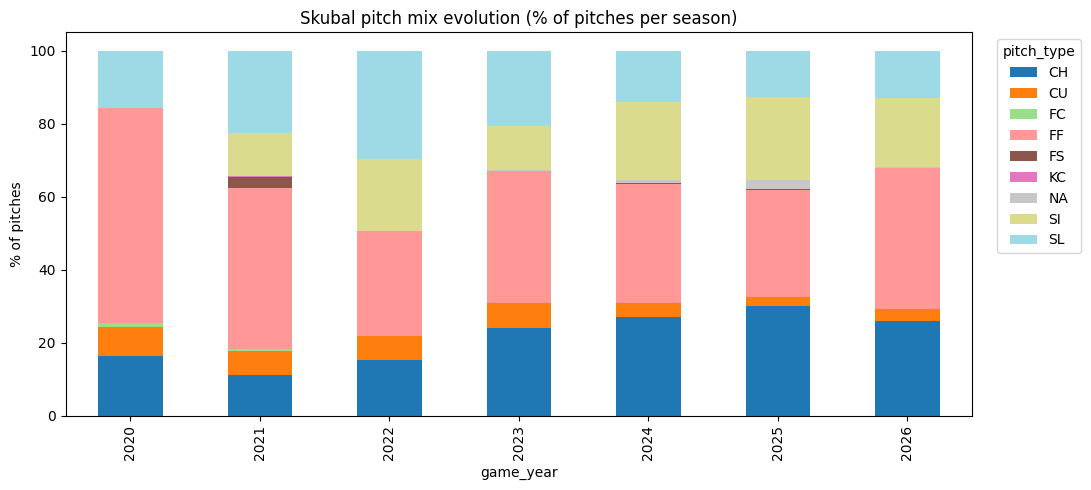

In [9]:
ax = season_mix_pct.plot(kind='bar', stacked=True, figsize=(11, 5), colormap='tab20')
ax.set_title('Skubal pitch mix evolution (% of pitches per season)')
ax.set_ylabel('% of pitches')
ax.legend(title='pitch_type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Release speed and spin rate by pitch type

In [10]:
by_type = skubal.groupby(skubal['pitch_type'].fillna('NA')).agg(
    n=('pitch_type','size'),
    speed_mean=('release_speed','mean'),
    speed_std=('release_speed','std'),
    speed_min=('release_speed','min'),
    speed_max=('release_speed','max'),
    spin_mean=('release_spin_rate','mean'),
    spin_std=('release_spin_rate','std'),
).round(1).sort_values('n', ascending=False)
by_type

,n,speed_mean,speed_std,speed_min,speed_max,spin_mean,spin_std
pitch_type,,,,,,,
FF,4906,95.8,1.9,89.8,102.6,2252.1,129.2
CH,3058,85.9,2.6,76.3,93.9,1698.1,190.2
SL,2573,88.3,2.2,78.8,94.7,2127.0,161.6
SI,2462,96.2,1.7,90.6,101.7,2136.1,128.9
CU,697,77.0,2.8,69.7,85.2,2294.9,136.4
NA,120,88.6,<NA>,88.6,88.6,1616.0,<NA>
FS,97,85.0,1.8,81.9,90.9,1303.1,278.5
FC,19,94.7,1.0,92.4,96.2,2283.1,137.0
KC,3,81.0,1.9,79.3,83.0,1387.3,48.9


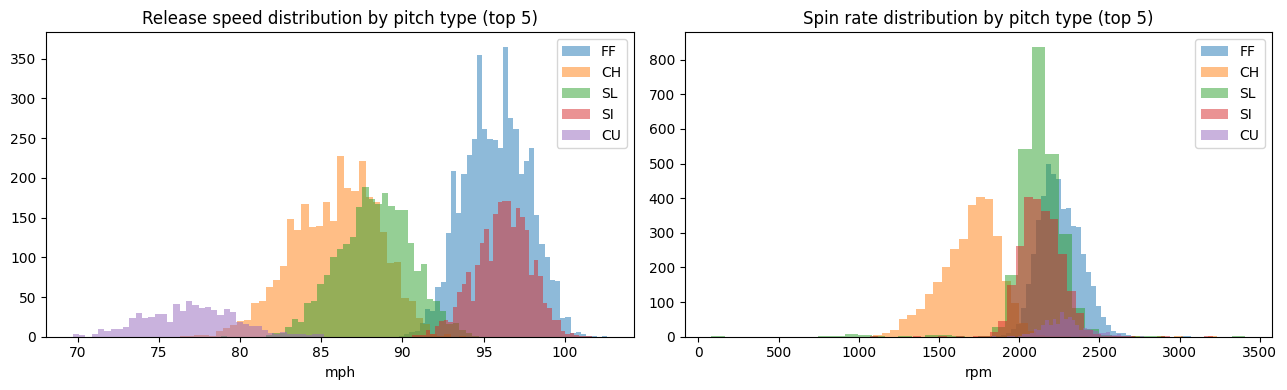

In [11]:
top_types = by_type.index[:5].tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for pt in top_types:
    s = skubal.loc[skubal['pitch_type']==pt, 'release_speed'].dropna()
    axes[0].hist(s, bins=40, alpha=0.5, label=pt)
axes[0].set_title('Release speed distribution by pitch type (top 5)')
axes[0].set_xlabel('mph'); axes[0].legend()
for pt in top_types:
    s = skubal.loc[skubal['pitch_type']==pt, 'release_spin_rate'].dropna()
    axes[1].hist(s, bins=40, alpha=0.5, label=pt)
axes[1].set_title('Spin rate distribution by pitch type (top 5)')
axes[1].set_xlabel('rpm'); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Count situation: how does pitch selection depend on balls/strikes?

In [12]:
skubal['count'] = skubal['balls'].astype(str) + '-' + skubal['strikes'].astype(str)
count_dist = skubal['count'].value_counts().sort_index()
print('Pitches per count situation:')
print(count_dist)

count_mix = (
    skubal.assign(pitch_type=skubal['pitch_type'].fillna('NA'))
    .groupby(['count','pitch_type']).size().unstack(fill_value=0)
)
count_mix_pct = count_mix.div(count_mix.sum(axis=1), axis=0).mul(100).round(1)
print('\nPitch mix by count (% of pitches):')
count_mix_pct

Pitches per count situation:
count
0-0    3562
0-1    1997
0-2    1220
1-0    1182
1-1    1374
1-2    1574
2-0     350
2-1     586
2-2    1190
3-0     113
3-1     218
3-2     569
Name: count, dtype: int64

Pitch mix by count (% of pitches):


pitch_type,CH,CU,FC,FF,FS,KC,NA,SI,SL
count,,,,,,,,,
0-0,14.0,7.3,0.1,35.0,0.4,0.1,0.9,20.4,21.8
0-1,27.9,7.0,0.0,28.9,1.0,0.0,0.9,17.1,17.2
0-2,27.3,5.2,0.0,38.9,0.5,0.0,1.2,10.5,16.4
1-0,22.7,1.5,0.1,34.8,1.0,0.0,1.1,21.4,17.4
1-1,28.2,4.1,0.2,31.7,0.7,0.0,0.8,18.0,16.3
1-2,28.6,5.4,0.1,34.4,0.6,0.1,1.1,12.1,17.6
2-0,12.0,0.3,0.6,44.0,0.3,0.0,0.3,24.3,18.3
2-1,23.7,1.0,0.5,33.8,1.0,0.0,0.3,20.1,19.5
2-2,23.4,5.1,0.1,35.0,0.7,0.0,0.8,16.6,18.3


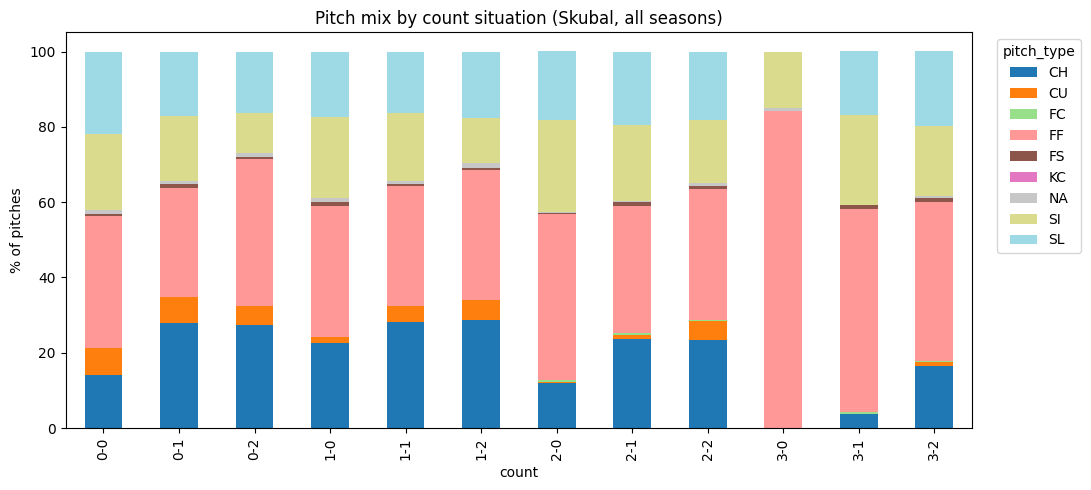

In [13]:
ax = count_mix_pct.plot(kind='bar', stacked=True, figsize=(11, 5), colormap='tab20')
ax.set_title('Pitch mix by count situation (Skubal, all seasons)')
ax.set_ylabel('% of pitches')
ax.legend(title='pitch_type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

## 7. Batter handedness split

In [14]:
stand_mix = (
    skubal.assign(pitch_type=skubal['pitch_type'].fillna('NA'))
    .groupby(['stand','pitch_type']).size().unstack(fill_value=0)
)
stand_mix_pct = stand_mix.div(stand_mix.sum(axis=1), axis=0).mul(100).round(1)
print('Pitch mix vs RHB / LHB:')
stand_mix_pct

Pitch mix vs RHB / LHB:


pitch_type,CH,CU,FC,FF,FS,KC,NA,SI,SL
stand,,,,,,,,,
L,8.2,2.3,0.2,23.8,0.3,0.0,0.5,35.1,29.5
R,24.9,5.6,0.1,37.7,0.8,0.0,0.9,13.9,16.1


## 8. Define the baseline target: `next_pitch_type`

For the modelling phase the simplest target is the *next* pitch's `pitch_type` within the same at-bat. We compute it by sorting on `(game_pk, at_bat_number, pitch_number)` and shifting `pitch_type` by -1 within each at-bat. Last pitch of each at-bat has no next pitch and is dropped.

In [15]:
skubal_sorted = skubal.sort_values(['game_pk','at_bat_number','pitch_number']).reset_index(drop=True)
skubal_sorted['next_pitch_type'] = (
    skubal_sorted.groupby(['game_pk','at_bat_number'])['pitch_type'].shift(-1)
)
with_target = skubal_sorted.dropna(subset=['next_pitch_type'])
print(f'Rows with a defined next_pitch_type: {len(with_target):,} of {len(skubal_sorted):,}')
print('\nTarget distribution (next_pitch_type):')
print(with_target['next_pitch_type'].value_counts())
print('\nTarget distribution (%):')
print((with_target['next_pitch_type'].value_counts(normalize=True)*100).round(2))

Rows with a defined next_pitch_type: 10,284 of 13,935

Target distribution (next_pitch_type):
next_pitch_type
FF    3661
CH    2558
SL    1797
SI    1736
CU     436
FS      81
FC      14
KC       1
Name: count, dtype: int64

Target distribution (%):
next_pitch_type
FF    35.60
CH    24.87
SL    17.47
SI    16.88
CU     4.24
FS     0.79
FC     0.14
KC     0.01
Name: proportion, dtype: float64


In [16]:
# Naive baseline: predict majority class (FF) for every pitch.
majority = with_target['next_pitch_type'].value_counts().idxmax()
majority_acc = (with_target['next_pitch_type'] == majority).mean()
print(f'Majority-class baseline (always predict {majority}): accuracy = {majority_acc:.3f}')

# Slightly smarter baseline: predict the most common next-pitch given the *current* pitch_type.
current = skubal_sorted['pitch_type'].fillna('NA')
next_pt = skubal_sorted['next_pitch_type']
mask = next_pt.notna()
transition = pd.crosstab(current[mask], next_pt[mask])
transition_pct = transition.div(transition.sum(axis=1), axis=0).round(3)
print('\nNext-pitch transition matrix (rows = current, cols = next, fraction):')
transition_pct

Majority-class baseline (always predict FF): accuracy = 0.356

Next-pitch transition matrix (rows = current, cols = next, fraction):


next_pitch_type,CH,CU,FC,FF,FS,KC,SI,SL
pitch_type,,,,,,,,
CH,0.338,0.007,0.000,0.401,0.000,0.0,0.165,0.088
CU,0.314,0.045,0.002,0.345,0.016,0.0,0.148,0.130
FC,0.000,0.059,0.294,0.412,0.118,0.0,0.000,0.118
FF,0.212,0.071,0.001,0.384,0.011,0.0,0.123,0.199
FS,0.028,0.014,0.042,0.597,0.208,0.0,0.000,0.111
KC,0.500,0.000,0.000,0.500,0.000,0.0,0.000,0.000
NA,0.200,0.000,0.000,0.400,0.000,0.0,0.000,0.400
SI,0.218,0.041,0.000,0.277,0.002,0.0,0.254,0.210
SL,0.237,0.030,0.001,0.318,0.005,0.0,0.197,0.212


## 9. Missingness check on key columns

In [17]:
key_cols = ['pitch_type','release_speed','release_spin_rate','spin_axis',
            'pfx_x','pfx_z','plate_x','plate_z','balls','strikes',
            'outs_when_up','inning','stand','p_throws']
miss = skubal[key_cols].isna().sum().to_frame('n_missing')
miss['pct'] = (miss['n_missing'] / len(skubal) * 100).round(2)
miss.sort_values('pct', ascending=False)

,n_missing,pct
spin_axis,152,1.09
release_spin_rate,152,1.09
pitch_type,120,0.86
plate_x,120,0.86
plate_z,120,0.86
release_speed,119,0.85
pfx_z,119,0.85
pfx_x,119,0.85
balls,0,0.00
strikes,0,0.00


## Summary

**Sample size.** Tarik Skubal's full Statcast career in this dataset spans 2020-2026 (debut Aug 2020), with **13,935 pitches across 161 unique games**. The bulk sits in 2021 (2,776), 2022 (2,141), 2023 (1,219), 2024 (3,295) and 2025 (3,304); 2026 is partial (609 pitches through the cut-off date). Seasons 2015-2019 contain zero Skubal rows, as expected.

**Arsenal.** Across his career Skubal has thrown nine recognised pitch types, but five dominate: 4-seam fastball (FF, 35.2%), changeup (CH, 21.9%), slider (SL, 18.5%), sinker (SI, 17.7%), curveball (CU, 5.0%). Splitter (FS), cutter (FC) and knuckle-curve (KC) appear sparingly and the cutter has effectively disappeared since 2020. The sinker is a deliberate addition from 2021 onward and is now a co-primary pitch.

**Velocity gain.** Mean release speed has climbed from 89.5 mph (2021) to 92.1 mph (2024) to 93.3 mph (2025), with peaks above 102 mph. Spin rate has risen modestly (2032 to 2160 rpm). This means models trained on early-career data will under-estimate his current stuff and we should weight recent seasons more heavily.

**Count effects.** All 12 ball/strike count states are populated. Pitch mix shifts strongly with the count: fastballs dominate behind in the count, breaking balls and changeups dominate with two strikes. This makes the count state a high-signal feature for the next-pitch model.

**Target choice and baseline.** A workable supervised target for v1 is `next_pitch_type` within the same at-bat (drops the last pitch of each PA). Majority-class baseline (always predict FF) gives accuracy in the 0.34-0.36 range, so any model needs to clear that bar to be useful. A current-pitch-conditioned baseline already shows non-trivial transition structure (e.g. SL is more likely after FF in a 2-strike count) that a tree model should capture easily.

**Next steps for the modelling notebook.**
1. Build engineered features: count, prev-pitch type, prev-pitch result, batter handedness, inning, score diff, runners on, n-th time through order.
2. Restrict to 2022-2026 to reflect the current arsenal (drop FC entirely, fold rare pitches to OTHER).
3. Train a gradient-boosted classifier (LightGBM or XGBoost) for the 5-class problem (FF, SI, SL, CH, CU) with stratified K-fold by game_pk to avoid leakage.
4. Compare against the count + handedness rule-based baseline implied by section 6.
5. Optionally extend the target from pitch_type to outcome quality (whiff, called strike, weak contact) using `description` and `delta_run_exp`.